# Facial verification with a Siamese network

This notebook develops and evaluates a **1:1 biometric verification system**: given a claimed identity, it compares a probe face with enrolled reference images and accepts or rejects the claim. A Siamese network maps both images through a shared embedding and converts their absolute embedding distance into a similarity score.

The project focuses on reproducible training, leakage-safe testing, and biometric error analysis. It reports genuine/impostor score distributions, FMR, FNMR, a DET curve, EER, d-prime, transaction-level FAR/FRR, and latency. Overview, interpretation, and complete references are in [the README](../Readme.md).

In [1]:
# Run configuration: use the shipped model and existing images by default.
TRAIN = True
CAPTURE = True

## Environment

Follow the pinned Python 3.11 setup in the [README](../Readme.md), select the project kernel, and run cells in order. Training and webcam capture are disabled by default. Set `TRAIN = True` only when intentionally creating a new model; set `CAPTURE = True` only when collecting local images.

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import os, sys, tensorflow as tf

print("Using Python" + sys.executable)

USE_GPU = os.environ.get("USE_GPU", "0") == "1"
gpus = tf.config.list_physical_devices("GPU")

try:
    if USE_GPU and gpus:
        if sys.platform == "darwin":
            tf.config.optimizer.set_experimental_options({"disable_meta_optimizer": True}) #dodge the known slicon Grappler crash
        print(f"GPU enabled ({len(gpus)} device[s])")
    elif USE_GPU and not gpus:
        hint = "pip install tensorflow-metal==1.2.0" if sys.platform == "darwin" else "install the CUDA build of tensorflow"
        print(f"USE_GPU=1 but no GPU visible -> run `{hint}`, then restart the kernel. Using CPU for now.")
    else:
        tf.config.set_visible_devices([], "GPU") # CPU only
        print("CPU mode (USE_GPU=0)")
except RuntimeError as e:                          # set_visible_devices after TF init (cell re-run)
    print("device config already applied, restart kernel to change. (", e, ")")

print("TensorFlow", tf.__version__, "| visible GPUs:", tf.config.get_visible_devices("GPU"))

Using Python/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/.venv/bin/python
GPU enabled (1 device[s])
TensorFlow 2.16.2 | visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data acquisition

Change the person and rerun to enroll a new person. You need to collect 3 sets of images for the enrolled person:
anchor, positive and verification.

In [4]:
from pathlib import Path

# Each locally recorded person lives in ../data/<name>/{anchor, positive, verification}.
# Change PERSON when enrolling a new person. Every complete person folder is used for training.
PERSON = 'justin'

def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'Readme.md').is_file() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not locate the project root. Start the notebook from inside this repository.')

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data'
MODELS_ROOT = PROJECT_ROOT / 'models'
NEG_PATH = DATA_ROOT / 'negative'  # LFW is used only as an impostor source

def person_paths(data_root, person):
    return {split: data_root / person / split for split in ('anchor', 'positive', 'verification')}

capture_paths = person_paths(DATA_ROOT, PERSON)
ANC_PATH, POS_PATH, VER_PATH = (capture_paths[split] for split in ('anchor', 'positive', 'verification'))
print(f'capture PERSON={PERSON}  ->  anchor={ANC_PATH}')

capture PERSON=justin  ->  anchor=/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor


In [5]:
# Skip extract/copy if negatives already populated
existing = len(list(NEG_PATH.glob("*.jpg")))
if existing > 1000:
    print(f"Negatives already in place ({existing} imgs) -> skipping download")
else:
    import kagglehub, shutil, tarfile

    download_root = Path(kagglehub.dataset_download("atulanandjha/lfwpeople")) #https://www.kaggle.com/datasets/atulanandjha/lfwpeople

    # 1. Extract the tgz
    with tarfile.open(download_root / 'lfw-funneled.tgz') as tar:
        tar.extractall(download_root)
    # 2. Find all jpgs in all subfolders and copy flat
    NEG_PATH.mkdir(parents=True, exist_ok=True)
    for image in download_root.rglob("*.jpg"):
        shutil.copy2(image, NEG_PATH / image.name)

    print("Data downloaded!")

Negatives already in place (13233 imgs) -> skipping download


## Capture/enfroll face data with the webcam

Press `a` for anchor references, `p` for positives, `v` for held-out verificaton probes, and `q` or Escape to stop.

- performance improved by using just one `cv2.waitKey(1)` check per loop, instead of one check for each key. This makes the webcam feed more responsive and less laggy.
- added v key to capture held-out verification selfies for evaluation (genuine probes).

In [7]:
import uuid

def capture_faces():
    for path in capture_paths.values():
        path.mkdir(parents=True, exist_ok=True)
    window_name = 'frame'
    cap = cv2.VideoCapture(0)
    frame = None
    crop = 400

    try:
        if not cap.isOpened():
            raise RuntimeError('Could not open webcam')
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

        while True:
            ret, frame = cap.read()
            if not ret or frame is None:
                print('Webcam read failed, stopping capture loop.')
                break

            h, w = frame.shape[:2]
            y0 = max((h - crop) // 2, 0)
            x0 = max((w - crop) // 2, 0)
            frame = frame[y0:y0+crop, x0:x0+crop, :]
            cv2.imshow(window_name, frame)

            key = cv2.waitKey(1) & 0xFF
            target = {ord('a'): ANC_PATH, ord('p'): POS_PATH, ord('v'): VER_PATH}.get(key)
            if target:
                imgname = target / f'{uuid.uuid1()}.jpg'
                if not cv2.imwrite(str(imgname), frame):
                    raise OSError(f'Could not write image to {imgname}')
            elif key in (ord('q'), 27):
                break

            if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
                break
    except KeyboardInterrupt:
        print('Capture interrupted by user.')
    finally:
        cap.release()
        cv2.destroyAllWindows()
        cv2.waitKey(1)

if CAPTURE:
    capture_faces()
else:
    print('Capture skipped (CAPTURE=False).')

## Personalized pair construction and leakage controls

Only locally recorded identities (with anchor/positive) provide genuine training pairs:

- **training genuine (label 1):** `anchor` versus `positive` from the same locally captured person;
- **training impostor (label 0):** a locally captured training image versus an LFW face; if multiple locally captured people exist, cross-person pairs from local captures are also created;
- **test genuine:** a held-out `verification` probe versus an `anchor` of the same locally captured person;
- **test impostor:** a held-out local probe/reference versus an LFW identity excluded from training.

LFW identities are split before sampling so test impostors are people absent from the training-impostor pool. Local `verification` images never update the model. This evaluates a verifier specialized for the recorded people; it does **not** demonstrate genuine-pair generalization to unseen identities.

In [10]:
import itertools
import random
from collections import defaultdict

RANDOM_SEED = 42
LFW_TRAIN_RATIO = 0.7
LFW_TEST_RATIO = 0.15
TRAIN_GENUINE_PER_PERSON = 1000
TEST_GENUINE_PER_PERSON = 300
CROSS_PERSON_NEGATIVE_FRACTION = 0.5  # used only when at least two locally captured people exist

def discover_local_images(data_root):
    local_images = {}
    for person_root in sorted(path for path in data_root.iterdir() if path.is_dir()):
        split_paths = {split: person_root / split for split in ('anchor', 'positive', 'verification')}
        if not any(path.is_dir() for path in split_paths.values()):
            continue
        missing_directories = [split for split, path in split_paths.items() if not path.is_dir()]
        if missing_directories:
            print(f'Skipping incomplete locally captured person {person_root.name}: missing folders {missing_directories}')
            continue
        images = {split: sorted(str(path) for path in directory.glob('*.jpg')) for split, directory in split_paths.items()}
        missing = [split for split, paths in images.items() if not paths]
        if missing:
            print(f'Skipping incomplete locally captured person {person_root.name}: no JPG images in {missing}')
            continue
        local_images[person_root.name] = images
    if not local_images:
        raise RuntimeError('No complete locally captured people found under data/<person>/{anchor,positive,verification}.')
    return local_images

def balanced_genuine_pairs(left_by_person, right_by_person, target_per_person, seed):
    rng = random.Random(seed)
    candidates = {}
    for person in sorted(left_by_person):
        pairs = [(a, b, 1.0) for a in left_by_person[person] for b in right_by_person[person] if a != b]
        rng.shuffle(pairs)
        candidates[person] = pairs
    per_person = min(target_per_person, min(map(len, candidates.values())))
    if per_person == 0:
        raise RuntimeError('Cannot form genuine pairs for every locally captured person.')
    return [pair for person in candidates for pair in candidates[person][:per_person]], per_person

def make_impostor_pairs(local_pool, lfw_pool, total, cross_left_pool, cross_right_pool, seed):
    rng = random.Random(seed)
    people = sorted(local_pool)
    lfw_identities = sorted(lfw_pool)
    if not lfw_identities:
        raise RuntimeError('The selected LFW split has no identities.')

    identity_pairs = list(itertools.combinations(people, 2))
    n_cross = round(total * CROSS_PERSON_NEGATIVE_FRACTION) if identity_pairs else 0
    pairs = []
    for _ in range(n_cross):
        person_a, person_b = rng.choice(identity_pairs)
        pairs.append((rng.choice(cross_left_pool[person_a]), rng.choice(cross_right_pool[person_b]), 0.0))
    for _ in range(total - n_cross):
        person = rng.choice(people)
        identity = rng.choice(lfw_identities)
        pairs.append((rng.choice(local_pool[person]), rng.choice(lfw_pool[identity]), 0.0))
    return pairs

def build_pair_splits(local_images, negative_root, seed=RANDOM_SEED):
    lfw_by_identity = defaultdict(list)
    for path in sorted(negative_root.glob('*.jpg')):
        lfw_by_identity[path.stem.rsplit('_', 1)[0]].append(str(path))

    lfw_identities = sorted(lfw_by_identity)
    split_rng = random.Random(seed)
    split_rng.shuffle(lfw_identities)
    train_cut = round(LFW_TRAIN_RATIO * len(lfw_identities))
    test_cut = train_cut + round(LFW_TEST_RATIO * len(lfw_identities))
    train_ids = lfw_identities[:train_cut]
    test_ids = lfw_identities[train_cut:test_cut]
    operational_ids = lfw_identities[test_cut:]
    train_lfw = {identity: lfw_by_identity[identity] for identity in train_ids}
    test_lfw = {identity: lfw_by_identity[identity] for identity in test_ids}
    operational_lfw = {identity: lfw_by_identity[identity] for identity in operational_ids}

    anchors = {person: images['anchor'] for person, images in local_images.items()}
    positives = {person: images['positive'] for person, images in local_images.items()}
    verification = {person: images['verification'] for person, images in local_images.items()}
    training_images = {person: anchors[person] + positives[person] for person in local_images}

    train_genuine, n_train_per_person = balanced_genuine_pairs(anchors, positives, TRAIN_GENUINE_PER_PERSON, seed + 1)
    test_genuine, n_test_per_person = balanced_genuine_pairs(verification, anchors, TEST_GENUINE_PER_PERSON, seed + 2)
    train_impostor = make_impostor_pairs(training_images, train_lfw, len(train_genuine), anchors, positives, seed + 3)
    test_impostor = make_impostor_pairs(verification, test_lfw, len(test_genuine), verification, anchors, seed + 4)

    train_pairs = train_genuine + train_impostor
    test_pairs = test_genuine + test_impostor
    random.Random(seed + 5).shuffle(train_pairs)
    random.Random(seed + 6).shuffle(test_pairs)

    all_lfw_paths = {path for paths in lfw_by_identity.values() for path in paths}
    verification_paths = {path for images in verification.values() for path in images}
    assert all(label == 0.0 for a, b, label in train_pairs + test_pairs if a in all_lfw_paths or b in all_lfw_paths)
    assert not ({path for pair in train_pairs for path in pair[:2]} & verification_paths)
    assert set(train_ids).isdisjoint(test_ids)
    assert set(train_ids).isdisjoint(operational_ids)
    assert set(test_ids).isdisjoint(operational_ids)

    print(f'genuine pairs per identity: {n_train_per_person} train / {n_test_per_person} held-out test')
    print(f'LFW impostor identities: {len(train_ids)} train / {len(test_ids)} test / {len(operational_ids)} operational')
    return train_pairs, test_pairs, operational_lfw

local_images = discover_local_images(DATA_ROOT)
train_pairs, test_pairs, operational_lfw = build_pair_splits(local_images, NEG_PATH)
print(f'locally captured identities: {len(local_images)} -> {sorted(local_images)}')
print(f'pairs: {len(train_pairs)} train / {len(test_pairs)} test (balanced genuine/impostor)')

genuine pairs per identity: 1000 train / 300 held-out test
LFW impostor identities: 4024 train / 862 test / 863 operational
locally captured identities: 1 -> ['justin']
pairs: 2000 train / 600 test (balanced genuine/impostor)


In [11]:
def preprocess(file_path):
    """resize and normalize image"""
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)

    img = tf.image.resize(img, (100,100))
    img = img / 255.0

    return img

# Create a labeled dataset

In [12]:
def make_dataset(pairs, training):
    dataset = tf.data.Dataset.from_tensor_slices((
        [pair[0] for pair in pairs],
        [pair[1] for pair in pairs],
        [pair[2] for pair in pairs],
    ))
    if training:
        dataset = dataset.shuffle(min(len(pairs), 1024), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(
        lambda input_img, validation_img, label: (preprocess(input_img), preprocess(validation_img), label),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.batch(16).prefetch(tf.data.AUTOTUNE)

# Do not cache decoded pair tensors: memory grows quickly when more locally captured people are added.
train_data = make_dataset(train_pairs, training=True)
test_data = make_dataset(test_pairs, training=False)
print(f'train_data batches={len(train_data)}  |  test_data batches={len(test_data)}')

train_data batches=125  |  test_data batches=38


2026-07-14 20:28:41.274486: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-14 20:28:41.274525: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-14 20:28:41.274531: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-14 20:28:41.274828: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-14 20:28:41.274849: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [13]:
# View the unprocessed pair structure without decoding images.
for sample in train_pairs[:5]:
    print(sample)

('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/96e062ca-7fb1-11f1-92b0-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/positive/ec25ce04-5da2-11f1-ba05-3e4fef0134de.jpg', 1.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/7c71eb10-7562-11f1-a751-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/positive/91274c9a-7fb1-11f1-92b0-3e4fef0134de.jpg', 1.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/e00565b2-5da2-11f1-ba05-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/negative/Liu_Xiaoqing_0001.jpg', 0.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/d684fb9c-5da2-11f1-ba05-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/positive/a092c194-6cb7-11f1-a15b-3e4fef0134de.jpg', 1.0)
('/Users/justingebert/Proj

## Model Creation

- architecture follows [Koch et al. 2015](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf)
- fixed a tutorial slip: `MaxPooling2D(64, (2,2))` set pool_size=64 (the 64 belongs to the Conv2D filters); paper uses 2x2 pooling windows, now `MaxPooling2D((2,2))`.

In [14]:
def make_embedding():
    inp = Input(shape=(100,100,3), name='input_image')

    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D((2,2), padding='same')(c1)

    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D((2,2), padding='same')(c2)

    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D((2,2), padding='same')(c3)

    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=inp, outputs=d1, name='embedding')

In [15]:
embedding = make_embedding()
embedding.summary(print_fn=print)

Model: "embedding"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼──────────────────────

# Siamese L1 Distance class

In [16]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

# Siamese model

In [17]:
def make_siamese_model():

    input_image = Input(name='input_img', shape=(100,100,3))

    validation_image = Input(name='validation_img', shape=(100,100,3))

    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))

    #break down into one sigmoid value
    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [18]:
siamese_model = make_siamese_model()
siamese_model.summary(print_fn=print)

Model: "SiameseNetwork"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │         

## Training
- removed checkpoint callback to speed up training, since the model is small and trains quickly.

In [19]:
loss = tf.losses.BinaryCrossentropy()
opt = tf.optimizers.Adam(0.0001)

In [20]:
import time

@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        x = batch[:2]
        y = batch[2]
        y_pred = siamese_model(x, training=True)
        loss_value = loss(y, y_pred)

    grad = tape.gradient(loss_value, siamese_model.trainable_variables)
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss_value

def format_duration(seconds):
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f'{int(hours)}h {int(minutes)}m {seconds:.1f}s'
    if minutes:
        return f'{int(minutes)}m {seconds:.1f}s'
    return f'{seconds:.1f}s'

def train(data, EPOCHS):
    training_start = time.perf_counter()
    for epoch in range(1, EPOCHS+1):
        epoch_start = time.perf_counter()
        print(f'Epoch {epoch}/{EPOCHS}')
        progbar = tf.keras.utils.Progbar(len(data))
        for idx, batch in enumerate(data.as_numpy_iterator()):
            loss_value = train_step(batch)
            progbar.update(idx+1, [('loss', loss_value.numpy())])
        epoch_seconds = time.perf_counter() - epoch_start
        print(f'Epoch time: {format_duration(epoch_seconds)} ({epoch_seconds:.2f}s)')

    total_seconds = time.perf_counter() - training_start
    avg_epoch_seconds = total_seconds / EPOCHS if EPOCHS else 0
    print(f'Total training time: {format_duration(total_seconds)} ({total_seconds:.2f}s)')
    print(f'Average epoch time: {format_duration(avg_epoch_seconds)} ({avg_epoch_seconds:.2f}s)')

In [21]:
EPOCHS = 50
if TRAIN:
    train(train_data, EPOCHS)
    print('Finished training!')
else:
    print('Skipping training (TRAIN=False)')

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - loss: 0.0280
Epoch time: 16.3s (16.28s)
Epoch 2/50
  1/125 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step - loss: 0.0662

2026-07-14 20:29:19.146143: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - loss: 0.0271
Epoch time: 16.2s (16.25s)
Epoch 3/50
  1/125 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - loss: 0.0169

2026-07-14 20:29:35.394755: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 0.0067
Epoch time: 15.3s (15.32s)
Epoch 4/50
  1/125 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - loss: 4.8015e-04

...

2026-07-14 20:41:21.863564: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 1.2144e-06
Epoch time: 15.3s (15.31s)
Epoch 50/50
  1/125 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - loss: 2.3097e-07

2026-07-14 20:41:37.170068: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - loss: 7.4506e-09
Epoch time: 15.3s (15.29s)
Total training time: 12m 49.6s (769.63s)
Average epoch time: 15.4s (15.39s)
Finished training!


2026-07-14 20:41:52.462430: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Save trained model

In [22]:
if TRAIN:
    import datetime
    MODELS_ROOT.mkdir(parents=True, exist_ok=True)
    RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    MODEL_PATH = MODELS_ROOT / f'siamesemodel_{RUN_ID}.keras'
    siamese_model.save(MODEL_PATH)
    print('saved model ->', MODEL_PATH)

saved model -> /Users/justingebert/Projects/Uni/MA/biometrics/biometrics/models/siamesemodel_20260714_204207.keras


# Performance Evaluation

Biometric error metrics for the trained model, at two levels:

1. **Comparison level (match).** Raw 1:1 comparison scores, one probe vs one reference. Metrics: score **histogram**, **FMR**, **FNMR**, **DET curve**, **EER**, **d-prime**. Judges the model's score quality, threshold independent.
2. **Transaction level (decision).** One accept/reject **verification decision** per probe (comparison threshold + decision-level fusion over the gallery). Metrics: **FAR**, **FRR**. Judges model + threshold policy.

## Load the latest model

In [23]:
def latest_model(models_dir=MODELS_ROOT):
    paths = sorted(models_dir.glob('siamesemodel_*.keras'))
    if not paths:
        raise FileNotFoundError(f'No siamesemodel_*.keras in {models_dir}: train first, or run `git lfs pull`.')
    return paths[-1]

MODEL_PATH = latest_model()
print('loading model <-', MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})
if not TRAIN:
    print('PROVENANCE NOTE: retrain once before reporting results; older checkpoints used a different pair protocol.')

loading model <- /Users/justingebert/Projects/Uni/MA/biometrics/biometrics/models/siamesemodel_20260714_204207.keras


## Basic Model Performance Evaluation

The **held-out `test_data`** uses `verification` probes that never update the model and LFW impostor identities absent from the training-impostor pool. Quick evaluation to check for overfitting and general model performance.

- **acc**: fraction of pairs classified correctly.
- **prec**: of pairs called *same*, how many truly are (penalises false accepts).
- **rec**: of truly-*same* pairs, how many are caught (penalises false rejects).
- **f1**: single balance of precision and recall.
- **auc**: separation quality across all thresholds (0.5 = random, 1.0 = perfect).
- **train-vs-test gap**: how much worse test is than train, large positive = overfitting.

In [25]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def collect_pairs(ds):
    """Run the loaded model over a batched (input, validation, label) dataset -> (scores, labels)."""
    scores, labels = [], []
    for x1, x2, y in ds.as_numpy_iterator():
        p = model.predict([x1, x2], verbose=0).reshape(-1)
        scores.append(p)
        labels.append(y.reshape(-1))
    return np.concatenate(scores), np.concatenate(labels).astype(int)

def binary_metrics(scores, labels, thr=0.5):
    pred = (scores >= thr).astype(int)
    return dict(
        acc  = accuracy_score(labels, pred),
        prec = precision_score(labels, pred, zero_division=0),
        rec  = recall_score(labels, pred, zero_division=0),
        f1   = f1_score(labels, pred, zero_division=0),
        auc  = roc_auc_score(labels, scores),
    )

tr_s, tr_y = collect_pairs(train_data)
te_s, te_y = collect_pairs(test_data)
m_tr, m_te = binary_metrics(tr_s, tr_y), binary_metrics(te_s, te_y)

# one row per split; columns come from the metric dict keys, so the header and values stay in sync
print(f'{"":7}' + "".join(f"{c:>7}" for c in m_tr) + "   (n pairs)")
for name, m, n in [("train", m_tr, len(tr_y)), ("test", m_te, len(te_y))]:
    print(f"{name:<7}" + "".join(f"{v:7.3f}" for v in m.values()) + f"   ({n})")

print(f"\noverfit gap= {m_tr['acc'] - m_te['acc']:+.3f}   (large positive = overfitting)")
tn, fp, fn, tp = confusion_matrix(te_y, te_s >= 0.5).ravel()
print(f"test confusion: TP={tp} TN={tn} FP={fp} FN={fn}  (thr=0.5)")

2026-07-14 20:43:52.043345: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


           acc   prec    rec     f1    auc   (n pairs)
train    1.000  1.000  1.000  1.000  1.000   (2000)
test     0.998  0.997  1.000  0.998  1.000   (600)

overfit gap= +0.002   (large positive = overfitting)
test confusion: TP=300 TN=299 FP=1 FN=0  (thr=0.5)


2026-07-14 20:43:53.701658: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Score collection: genuine and impostor comparisons

Operational impostors are sampled one image per LFW identity from a third identity partition disjoint from both training and pair-test LFW identities. Genuine and impostor images still come from different capture sources, so source/crop shortcuts remain an important limitation.

In [26]:
import random
random.seed(RANDOM_SEED)

GEN_DIR = VER_PATH          # genuine probes
N_REFS  = 15                # how many references to enroll; None = use all in ANC_PATH
N_IMPOSTORS = 300           # LFW faces sampled as impostor probes

MATCH_THR    = 0.6        # comparison level: comparison score > MATCH_THR -> match
DECISION_THR = 0.6          # transaction level: accept the claim if the FRACTION of matched refs > DECISION_THR

def list_jpgs(directory):
    return sorted(str(path) for path in directory.glob('*.jpg'))

ref_paths = list_jpgs(ANC_PATH)
gen_paths = list_jpgs(GEN_DIR)
if not ref_paths:
    raise FileNotFoundError(f'No reference images in {ANC_PATH}.')
if not gen_paths:
    raise FileNotFoundError(f'No genuine probes in {GEN_DIR}, record verfication images with the `v` key in the capture cell.')

if N_REFS is not None:
    ref_paths = random.sample(ref_paths, min(N_REFS, len(ref_paths)))   # seeded -> reproducible gallery
gen_paths = [p for p in gen_paths if p not in set(ref_paths)]           # safety: drop any overlap (self-match)
imp_ids = random.sample(sorted(operational_lfw), min(N_IMPOSTORS, len(operational_lfw)))
imp_paths = [random.choice(operational_lfw[identity]) for identity in imp_ids]  # one face per unseen operational identity

ref_batch = tf.stack([preprocess(p) for p in ref_paths])   # (R, 100, 100, 3)

def comparison_scores(probe_path):
    """One probe vs every reference -> R comparison scores"""
    probe = tf.repeat(tf.expand_dims(preprocess(probe_path), 0), ref_batch.shape[0], axis=0)
    return model.predict([probe, ref_batch], verbose=0).reshape(-1)

def verification_decision(scores):
    """Transaction level: accept the claim if more than DECISION_THR of the refs matched (score > MATCH_THR)."""
    return bool(np.mean(scores > MATCH_THR) > DECISION_THR)

def collect(paths):
    """-> (flattened comparison scores, per-probe verification decisions) for a set of probes."""
    scores, decisions = [], []
    for p in paths:
        s = comparison_scores(p)
        scores.extend(s)
        decisions.append(verification_decision(s))
    return np.array(scores), decisions

# comparison scores + verification decisions
genuine_scores, genuine_decisions = collect(gen_paths)
impostor_scores, impostor_decisions = collect(imp_paths)

print(f'references(gallery)={len(ref_paths)} from {ANC_PATH.name}  |  '
      f'genuine probes={len(gen_paths)} from {GEN_DIR.name} -> {genuine_scores.size} comparisons  |  '
      f'impostor probes={len(imp_paths)} -> {impostor_scores.size} comparisons')
if genuine_scores.size == 0:
    print('No genuine data yet - record held-out selfies with the `v` key (Capture cell), then re-run.')


references(gallery)=15 from anchor  |  genuine probes=62 from verification -> 930 comparisons  |  impostor probes=300 -> 4500 comparisons


## Genuine vs impostor score histogram (comparison level)

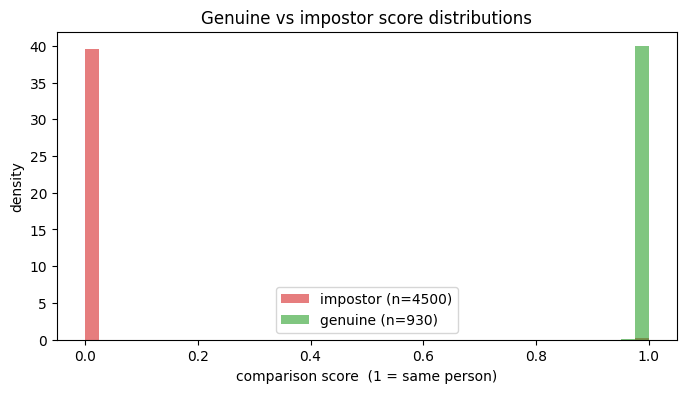

In [27]:
plt.figure(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
plt.hist(impostor_scores, bins=bins, alpha=0.6, density=True, color='tab:red', label=f'impostor (n={impostor_scores.size})')
plt.hist(genuine_scores, bins=bins, alpha=0.6, density=True, color='tab:green', label=f'genuine (n={genuine_scores.size})')
plt.xlabel('comparison score  (1 = same person)')
plt.ylabel('density')
plt.title('Genuine vs impostor score distributions')
plt.legend()
plt.show()

## FMR / FNMR / DET / EER / d-prime (comparison level, matcher)
- FMR(t)  = impostor scores >= t  (impostors wrongly matched)
- FNMR(t) = genuine  scores <  t  (genuines wrongly rejected)

EER      = 0.005  at threshold 0.986
d-prime  = 17.439  (higher = better separated)
At MATCH_THR=0.6: FMR=0.006 (29/4500), FNMR=0.000 (0/930)


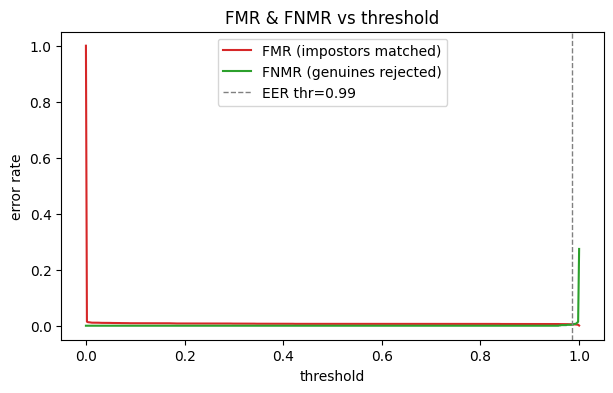

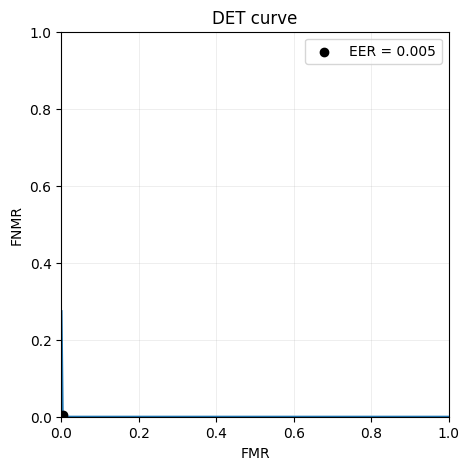

In [28]:
thresholds = np.linspace(0, 1, 501)
fmr = np.array([np.mean(impostor_scores >= t) for t in thresholds])
fnmr = np.array([np.mean(genuine_scores < t) for t in thresholds])
i = np.argmin(np.abs(fmr - fnmr))                 # EER: FMR ~= FNMR
eer, eer_thr = (fmr[i] + fnmr[i]) / 2, thresholds[i]
dprime = (genuine_scores.mean() - impostor_scores.mean()) / np.sqrt((genuine_scores.var() + impostor_scores.var()) / 2)
print(f'EER      = {eer:.3f}  at threshold {eer_thr:.3f}')
print(f"d-prime  = {dprime:.3f}  (higher = better separated)")
selected_fmr = np.mean(impostor_scores >= MATCH_THR)
selected_fnmr = np.mean(genuine_scores < MATCH_THR)
selected_fm = np.sum(impostor_scores >= MATCH_THR)
selected_fnm = np.sum(genuine_scores < MATCH_THR)
print(f'At MATCH_THR={MATCH_THR}: FMR={selected_fmr:.3f} ({selected_fm}/{impostor_scores.size}), '
      f'FNMR={selected_fnmr:.3f} ({selected_fnm}/{genuine_scores.size})')

# FMR & FNMR vs threshold
plt.figure(figsize=(7, 4))
plt.plot(thresholds, fmr, color='tab:red', label='FMR (impostors matched)')
plt.plot(thresholds, fnmr, color='tab:green', label='FNMR (genuines rejected)')
plt.axvline(eer_thr, ls='--', color='gray', lw=1, label=f'EER thr={eer_thr:.2f}')
plt.xlabel('threshold'); plt.ylabel('error rate')
plt.title('FMR & FNMR vs threshold'); plt.legend(); plt.show()

# DET-style error trade-off: FNMR vs FMR across thresholds
plt.figure(figsize=(5, 5))
plt.plot(fmr, fnmr, color='tab:blue')
plt.scatter([eer], [eer], color='k', zorder=5, label=f'EER = {eer:.3f}')
plt.xlabel('FMR'); plt.ylabel('FNMR'); plt.title('DET curve')
plt.xlim(0, 1); plt.ylim(0, 1); plt.grid(alpha=0.3); plt.legend(); plt.show()

## FAR / FRR (Transaction level, decider)

In [29]:
imp_dec = np.array(impostor_decisions)
far = imp_dec.mean() if imp_dec.size else float('nan')
print(f'operating point: MATCH_THR={MATCH_THR}, DECISION_THR={DECISION_THR}')
print(f'FAR (transaction) = {far:.3f}   ({imp_dec.sum()}/{imp_dec.size} impostors accepted)')

gen_dec = np.array(genuine_decisions)
frr = 1 - gen_dec.mean()
print(f'FRR (transaction) = {frr:.3f}   ({(~gen_dec).sum()}/{gen_dec.size} genuines rejected)')

operating point: MATCH_THR=0.6, DECISION_THR=0.6
FAR (transaction) = 0.003   (1/300 impostors accepted)
FRR (transaction) = 0.000   (0/62 genuines rejected)


## Inference latency

How long one verification transaction takes (responsiveness/throughput).
- The first call traces the TF graph, and CPU scheduling / thermal throttling jitter the rest. So: warm up, then repeat

In [30]:
# Inference latency (direct model call; no predict() Python/callback overhead)
import time

def bench(fn, n=100, warmup=10):
    """Warm up (discard graph tracing / first-call cost), then time n repeats -> ms array."""
    for _ in range(warmup):
        fn()
    t = np.empty(n)
    for k in range(n):
        t0 = time.perf_counter()
        fn()
        t[k] = (time.perf_counter() - t0) * 1e3   # ms
    return t

def summarize(name, t):
    print(f'{name:22s} median={np.median(t):6.2f}  mean={t.mean():6.2f}  'f'p95={np.percentile(t,95):6.2f}  min={t.min():6.2f}  std={t.std():5.2f} ms  (n={t.size})')

R = ref_batch.shape[0]
probe_all = tf.repeat(tf.expand_dims(preprocess(gen_paths[0]), 0), R, axis=0)  # 1 probe vs all refs
one_a = tf.expand_dims(preprocess(gen_paths[0]), 0)
one_b = ref_batch[:1]

t_pair = bench(lambda: model([one_a, one_b], training=False))         # single 1:1 comparison
t_full = bench(lambda: model([probe_all, ref_batch], training=False)) # full transaction (1 probe vs all refs)

print(f'device: {"GPU" if tf.config.get_visible_devices("GPU") else "CPU"}')
summarize('1:1 comparison', t_pair)
summarize(f'full transaction (R={R})', t_full)
print(f'per-reference marginal ~ {t_full.mean()/R:.2f} ms   throughput ~ {1000*R/t_full.mean():.0f} pairs/s')

# latency vs gallery size (more reference images -> slower decision, ~linear)
print('\nlatency vs number of reference images:')
for r in sorted({1, 5, 10, 25, R}):
    if r > R:
        continue
    pr = tf.repeat(tf.expand_dims(preprocess(gen_paths[0]), 0), r, axis=0)
    tr = bench(lambda pr=pr, r=r: model([pr, ref_batch[:r]], training=False), n=50)
    print(f'  R={r:3d}  median={np.median(tr):6.2f} ms')


device: GPU
1:1 comparison         median=  5.84  mean=  5.97  p95=  6.71  min=  5.50  std= 0.36 ms  (n=100)
full transaction (R=15) median= 23.41  mean= 22.95  p95= 23.91  min=  5.83  std= 2.88 ms  (n=100)
per-reference marginal ~ 1.53 ms   throughput ~ 654 pairs/s

latency vs number of reference images:
  R=  1  median=  5.80 ms
  R=  5  median=  8.72 ms
  R= 10  median= 16.63 ms
  R= 15  median= 23.78 ms


## Interpretation template (complete after the final run)


| Evidence | Final value | What to interpret |
|---|---:|---|
| Held-out ROC-AUC | TBD | Separation of local held-out genuine probes from unseen LFW impostors |
| EER / EER threshold | TBD / TBD | Balanced comparison error and the score where FMR is approximately FNMR |
| d-prime | TBD | Standardized separation of genuine and impostor score distributions |
| FMR / FNMR at selected match threshold | TBD / TBD | Security-usability trade-off at the chosen comparison threshold |
| FAR / FRR at transaction policy | TBD / TBD | End-to-end accept/reject errors after gallery fusion |
| Median / p95 transaction latency | TBD / TBD ms | Typical responsiveness and slower-tail behavior |

### Results-ready narrative

1. **Held-out performance.** The personalized test ROC-AUC of **TBD** and train-test accuracy gap of **TBD** indicate **TBD** for new captures of the enrolled locally captured identities against unseen LFW impostors. Do not claim genuine matching for identities absent from training, and do not equate pair accuracy at threshold 0.5 with biometric security.
2. **Score separation.** Genuine scores are centered around **TBD**, while impostor scores are centered around **TBD**. Their overlap is **TBD**, consistent with d-prime **TBD**. State any visible skew or outliers because averages can hide difficult comparisons.
3. **Threshold trade-off.** EER is **TBD** at threshold **TBD**. Raising the threshold should reduce false matches but increase false non-matches; lowering it does the reverse. Explain why the selected operating threshold **TBD** fits the intended demonstration rather than claiming it is universally optimal.
4. **End-to-end decision.** With `MATCH_THR = TBD`, `DECISION_THR = TBD`, and **TBD** enrollment references, FAR is **TBD** and FRR is **TBD**. Compare these transaction errors with comparison-level FMR/FNMR and explain how majority-style gallery fusion changed the outcome.
5. **Practicality.** Median transaction latency is **TBD ms** and p95 is **TBD ms** on **TBD hardware/device**. This supports **TBD** for an interactive demo, while latency will grow with gallery size.
6. **Limitations.** Results apply to this model, dataset construction, enrollment gallery, capture conditions, and sampled impostors. LFW is an unconstrained research dataset, but it is not representative of every demographic or deployment condition. The evaluation does not test presentation attacks, face detection/alignment failures, long-term template aging, or multi-person identification. The modest number of genuine probes also makes FRR uncertain; report error counts beside rates.

The final README should present the same conclusions more briefly. Replace all placeholders only after one clean, top-to-bottom evaluation run and keep the run configuration, sample counts, thresholds, hardware, and model filename with the reported values.